In [1]:
import sys, os, gc
sys.path.insert(0, os.path.join('..'))   # project root on path

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import wrds
import polars as pl
import polars.selectors as cs
import pyarrow
import config

from src.utils import *
from sklearn.metrics import root_mean_squared_error, r2_score
from src.data_loading import *
from src.model import *
from abc import ABC, abstractmethod

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)

In [6]:
df_sp500 = fetch_sp500()
gspc = pd.read_parquet(config.GSPC_PATH_RAW)
gspc = gspc.dropna()
gspc['date'] = pd.to_datetime(gspc['date'])
gspc = gspc.drop(['vwretd', 'ewretd'], axis=1).reset_index(drop=True)
gspc.to_parquet(config.GSPC_PATH_CLEAN)
gspc.head()

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\dario\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Data saved to c:\Users\dario\Documents\Academique\EPFL\Master\MA-2\Machine Learning for Finance\ML-For-Finance-Project-LeoWunderli-329314-DarioFrey-344524\notebooks\..\data\raw\gspc.parquet


,date,sprtrn
0,1962-07-03,0.0113
1,1962-07-05,0.0057
2,1962-07-06,-0.0113
3,1962-07-09,0.0068
4,1962-07-10,0.0115


---
# Functions

In [2]:
split_batch_dict = merge_and_batch()

features : 4253 doublons (date, PERMNO) supprimés
cz       : 0 doublons (date) supprimés
vix      : 0 doublons (date) supprimés
Number of unique PERMNO in dataset : 7355
Number of unique dates in df_tmp   : 7577
Total unique dates: 5303
  train: 2000-01-03 → 2014-10-03  (3712 dates, 70.0%)
  val  : 2014-10-06 → 2017-11-29  (795 dates, 15.0%)
  test : 2017-11-30 → 2021-01-29  (796 dates, 15.0%)
After dropna - train: 1014655, val: 121412, test: 100879
Total unique dates: 5303
  train: 2000-01-03 → 2014-10-03  (3712 dates, 70.0%)
  val  : 2014-10-06 → 2017-11-29  (795 dates, 15.0%)
  test : 2017-11-30 → 2021-01-29  (796 dates, 15.0%)
After dropna - train: 1001943, val: 117287, test: 104174
Total unique dates: 5303
  train: 2000-01-03 → 2014-10-03  (3712 dates, 70.0%)
  val  : 2014-10-06 → 2017-11-29  (795 dates, 15.0%)
  test : 2017-11-30 → 2021-01-29  (796 dates, 15.0%)
After dropna - train: 1025088, val: 123502, test: 105085
Total unique dates: 5303
  train: 2000-01-03 → 2014-10-03  (37

---
# Train and predict with each batch using Lasso

In [3]:
from sklearn.linear_model import LassoCV, Lasso, lasso_path

models, y_preds = basic_lasso(split_batch_dict, signal_transform=False)


Alpha optimal for batch_1 : 0.000002
R² train for batch_1: 0.0048
R² val batch_1: -0.0035
Alpha optimal for batch_2 : 0.000012
R² train for batch_2: 0.0045
R² val batch_2: -0.0020
Alpha optimal for batch_3 : 0.000015
R² train for batch_3: 0.0040
R² val batch_3: -0.0019
Alpha optimal for batch_4 : 0.000009
R² train for batch_4: 0.0044
R² val batch_4: -0.0054
Alpha optimal for batch_5 : 0.000019
R² train for batch_5: 0.0041
R² val batch_5: -0.0030


---
# Train and predict with each batch using LightGBM

In [19]:
def basic_xgboost(
    split_batch_dict : dict,
    params : dict
):
    
    """"

    Unique batch test

    """
    # 1. Loop on each batch
    TARGET = 'target'
    
    models = {}
    y_preds = {}
    
    for batch in split_batch_dict:
        
        y_train = split_batch_dict[batch]['train'][TARGET]
        X_train = split_batch_dict[batch]['train'].drop([TARGET, 'ret', 'mkt_ret'], axis=1)
        train_set = lgb.Dataset(X_train, label=y_train)

        y_val = split_batch_dict[batch]['validation'][TARGET]
        X_val = split_batch_dict[batch]['validation'].drop([TARGET, 'ret', 'mkt_ret'], axis=1)
        val_set = lgb.Dataset(X_val, label=y_val)
    

        model = lgb.LGBMRegressor(metric='rmse')
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        y_preds[batch] = pd.DataFrame(y_pred_val, columns=['ret_pred'], index=y_val.index)
        models[batch] = model

        print("Training R2: ", r2_score(y_train, y_pred_train))
        print("Validation R2: ", r2_score(y_val, y_pred_val)) 
        
        
    return models, y_preds

In [ ]:
import lightgbm as lgb
import xgboost as  xgb
from sklearn.metrics import r2_score


params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

models, y_preds = basic_lightGBM(split_batch_dict, params)


NameError: name 'basic_xgboost' is not defined

---
# Post-processing strategy

In [ ]:
class Strategy(ABC):
    """Interface : prend un panel de signaux/prédictions, retourne des poids."""
    
    @abstractmethod
    def compute_weights(self, signals: pd.DataFrame) -> pd.DataFrame:
        """
        Args:
            signals : DataFrame MultiIndex (date, PERMNO) avec colonne 'prediction'
        Returns:
            DataFrame MultiIndex (date, PERMNO) avec colonne 'weight'
            (positif = long, négatif = short, somme libre selon la stratégie)
        """
        pass


class LongShortQuantile(Strategy):
    """Long top X%, short bottom Y% basé sur la prédiction."""
    def __init__(self, long_pct=0.20, short_pct=0.20, 
                 long_weight=0.50, short_weight=0.50):
        self.long_pct     = long_pct
        self.short_pct    = short_pct
        self.long_weight  = long_weight
        self.short_weight = short_weight
    
    def compute_weights(self, signals):
        def _rank_and_weight(g):
            n = len(g)
            ranks = g["prediction"].rank(pct=True)
            w = pd.Series(0.0, index=g.index)
            
            long_mask  = ranks >= (1 - self.long_pct)
            short_mask = ranks <= self.short_pct
            
            if long_mask.sum() > 0:
                w[long_mask]  =  self.long_weight  / long_mask.sum()
            if short_mask.sum() > 0:
                w[short_mask] = -self.short_weight / short_mask.sum()
            return w
        
        return signals.groupby(level="date", group_keys=False).apply(_rank_and_weight).to_frame("weight")


class TopK(Strategy):
    """Long-only sur les K meilleurs."""
    def __init__(self, k=10, total_weight=1.0):
        self.k = k
        self.total_weight = total_weight
    
    def compute_weights(self, signals):
        def _top_k(g):
            w = pd.Series(0.0, index=g.index)
            top_idx = g["prediction"].nlargest(self.k).index
            w[top_idx] = self.total_weight / self.k
            return w
        return signals.groupby(level="date", group_keys=False).apply(_top_k).to_frame("weight")


class BuyAndHold(Strategy):
    """Equal-weight figé sur l'univers initial."""
    def __init__(self, total_weight=1.0):
        self.total_weight = total_weight
    
    def compute_weights(self, signals):
        first_date = signals.index.get_level_values("date").min()
        initial_universe = signals.loc[first_date].index
        n = len(initial_universe)
        w_per_stock = self.total_weight / n
        
        # Construit un panel de poids constants
        dates = signals.index.get_level_values("date").unique()
        idx = pd.MultiIndex.from_product([dates, initial_universe], names=["date", "PERMNO"])
        return pd.DataFrame({"weight": w_per_stock}, index=idx)


class EqualWeightUniverse(Strategy):
    """Equal-weight sur tout l'univers à chaque date (benchmark passif)."""
    def __init__(self, total_weight=1.0):
        self.total_weight = total_weight
    
    def compute_weights(self, signals):
        def _ew(g):
            return pd.Series(self.total_weight / len(g), index=g.index)
        return signals.groupby(level="date", group_keys=False).apply(_ew).to_frame("weight")


class CostModel:
    """Tous les coûts d'exécution dans un seul objet."""
    
    def __init__(self, 
                 trading_cost: float = 0.001,
                 borrow_cost_annual: float = 0.01,
                 trading_days: int = 252):
        self.trading_cost = trading_cost
        self.borrow_cost_daily = borrow_cost_annual / trading_days
    
    def transaction_cost(self, w_prev: np.ndarray, w_curr: np.ndarray) -> float:
        """Coût = TC × turnover (somme des |Δw|)."""
        turnover = np.abs(w_curr - w_prev).sum()
        return self.trading_cost * turnover
    
    def borrow_cost(self, w_curr: np.ndarray) -> float:
        """Coût d'emprunt sur les positions short uniquement."""
        short_exposure = np.abs(np.minimum(w_curr, 0)).sum()
        return self.borrow_cost_daily * short_exposure
    
class Backtester:
    """
    Reçoit poids + retours + coûts → calcule l'évolution du portfolio.
    Ne sait RIEN de la stratégie.
    """
    
    def __init__(self, cost_model: CostModel = None, initial_capital: float = 1000):
        self.cost_model = cost_model or CostModel()
        self.N = initial_capital
    
    def run(self, weights: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
        """
        Args:
            weights : MultiIndex (date, PERMNO), colonne 'weight'
            returns : MultiIndex (date, PERMNO), colonne 'ret'
        Returns:
            DataFrame indexé par date avec portfolio_value, gross/net returns, costs
        """
        # Pivot en panneau date × PERMNO
        w_panel = weights["weight"].unstack(fill_value=0.0).sort_index()
        r_panel = returns["ret"].unstack(fill_value=0.0).sort_index()
        
        # Align colonnes
        common_cols = w_panel.columns.intersection(r_panel.columns)
        w_panel = w_panel[common_cols]
        r_panel = r_panel.reindex(index=w_panel.index, columns=common_cols, fill_value=0.0)
        
        dates = w_panel.index
        n = len(dates)
        
        portfolio_values = np.empty(n)
        gross_returns    = np.empty(n)
        net_returns      = np.empty(n)
        cumulative_costs = np.empty(n)
        
        pv = self.N
        total_cost = 0.0
        w_prev = np.zeros(len(common_cols))
        
        for t, date in enumerate(dates):
            w_curr = w_panel.iloc[t].values
            r_curr = r_panel.iloc[t].values
            
            # Coûts (en fraction de pv)
            tc     = self.cost_model.transaction_cost(w_prev, w_curr)
            borrow = self.cost_model.borrow_cost(w_curr)
            cost_frac = tc + borrow
            
            # P&L
            gross_ret = (w_curr * r_curr).sum()
            net_ret   = gross_ret - cost_frac
            
            portfolio_values[t] = pv
            gross_returns[t]    = gross_ret
            net_returns[t]      = net_ret
            total_cost         += cost_frac * pv
            cumulative_costs[t] = total_cost
            
            pv = pv * (1 + net_ret)
            w_prev = w_curr
        
        return pd.DataFrame({
            "portfolio_value" : portfolio_values,
            "gross_return"    : gross_returns,
            "net_return"      : net_returns,
            "cumulative_cost" : cumulative_costs,
        }, index=dates)

def random_sampling(
        df: pd.DataFrame,
        sample_number : int = 1,
        seed: int = 42
) -> pd.DataFrame:
    """
    Pour chaque date, tire un PERMNO aléatoire parmi ceux disponibles.

    Args:
        df    : DataFrame avec MultiIndex (date, PERMNO)
        seed  : graine pour la reproductibilité (default=42)

    Returns:
        DataFrame avec MultiIndex (date, PERMNO), un seul PERMNO par date
    """
    sampled = (
        df
        .groupby("date", group_keys=False)
        .apply(lambda g: g.sample(n=sample_number, random_state=seed))
    )

    return pd.DataFrame(sampled)

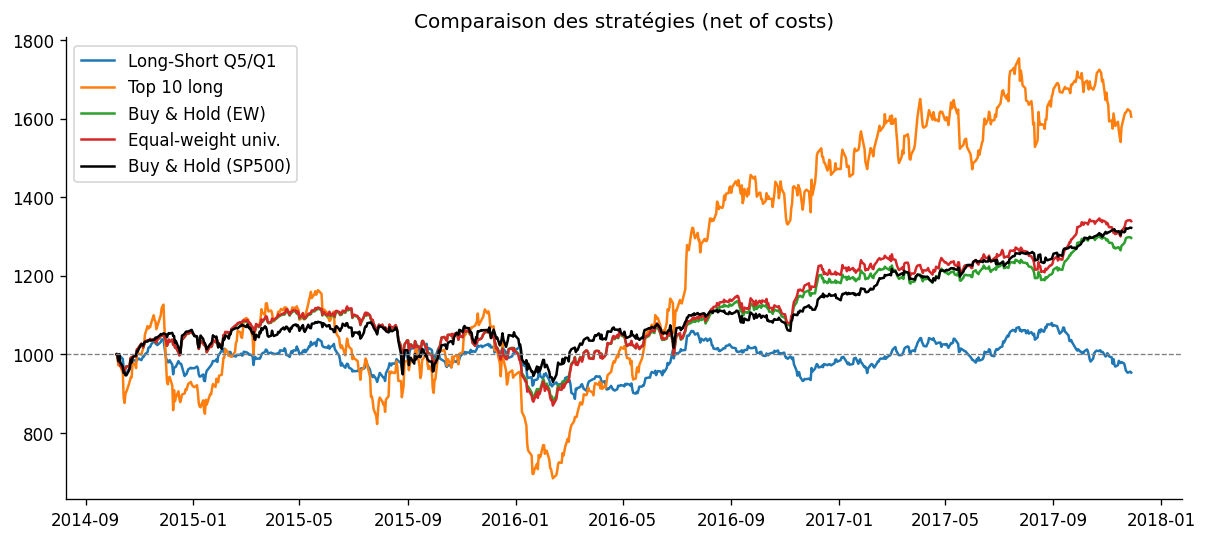

In [34]:

# ── Parameters ────────────────────────────────────────────────────────────────
N                  = 1000   # Capital initial
LONG_WEIGHT        = 0.50    # 50% long sur top xx%
SHORT_WEIGHT       = 0.10    # 10% short sur bottom xx%
TRADING_COST       = 0.001    # frais de transaction
BORROW_COST_ANNUAL = 0.01    # 1% coût d'emprunt annuel sur le short leg
TRADING_DAYS       = 252

BH, date_range = buy_and_hold(pd.read_parquet(config.GSPC_PATH_CLEAN), initial_capital=N, start_date=y_preds['batch_1'].index.min()[0], end_date=y_preds['batch_1'].index.max()[0])

cost_model = CostModel(trading_cost=TRADING_COST, borrow_cost_annual=BORROW_COST_ANNUAL)

strategies = {
    "Long-Short Q5/Q1" : LongShortQuantile(long_pct=0.10, short_pct=0.10),
    "Top 10 long"      : TopK(k=10),
    "Buy & Hold (EW)"  : BuyAndHold(),
    "Equal-weight univ.": EqualWeightUniverse(),
}

fig, ax = plt.subplots(figsize=(12, 5))

for label, strat in strategies.items():
    weights = strat.compute_weights(y_preds['batch_1'].rename(columns={'ret_pred' : 'prediction'}))
    result  = Backtester(cost_model, initial_capital=N).run(weights, split_batch_dict['batch_1']['validation'][['target']].rename(columns={'target' : 'ret'}))
    ax.plot(result.index, result["portfolio_value"], label=label)

ax.plot(result.index, BH.loc[0:BH.shape[0]-2], color='black', label='Buy & Hold (SP500)')

ax.axhline(1000, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Comparaison des stratégies (net of costs)")
ax.legend()
plt.show()

In [11]:
top_s, bottom_s = top_bottom(split_batch_dict, y_preds, threshold=0.99, y_true='validation')

# ── Paramètres ────────────────────────────────────────────────────────────────
N                  = 1000   # Capital initial
LONG_WEIGHT        = 0.50    # 50% long sur top xx%
SHORT_WEIGHT       = 0.10    # 10% short sur bottom xx%
TRADING_COST       = 0.001    # frais de transaction
BORROW_COST_ANNUAL = 0.01    # 1% coût d'emprunt annuel sur le short leg
TRADING_DAYS       = 252



portfolios, metrics = portfolio_value(top_s, bottom_s, N, LONG_WEIGHT, SHORT_WEIGHT, TRADING_COST, BORROW_COST_ANNUAL)
print(metrics.to_string(formatters={
    'total_return':      '{:+.2%}'.format,
    'annualized_return': '{:+.2%}'.format,
    'volatility':        '{:.2%}'.format,
    'sharpe_ratio':      '{:.2f}'.format,
    'max_drawdown':      '{:.2%}'.format,
}))

BH, date_range = buy_and_hold(pd.read_parquet(config.GSPC_PATH_CLEAN), initial_capital=N, start_date=y_preds['batch_1'].index.min()[0], end_date=y_preds['batch_1'].index.max()[0])

        total_return annualized_return volatility sharpe_ratio max_drawdown
batch                                                                      
batch_1      +41.46%           +11.64%     35.15%         0.33      -51.52%
batch_2     +142.71%           +32.50%     31.40%         1.04      -28.95%
batch_3      +55.22%           +14.98%     31.89%         0.47      -45.14%
batch_4      -70.82%           -32.36%     32.26%        -1.00      -76.06%
batch_5      -37.25%           -13.75%     32.55%        -0.42      -60.32%
